# <span style=color:blue> Numerical Simulation Laboratory #
## <span style=color:blue> Exercise lecture 4 ##
### Mattia Nasi 11590A ###

## <span style=color:red> 04.1 ##
In Statistical Mechanics the Maxwell–Boltzmann distribution is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The provided code already performs most of the calculations, i implemented the Maxwell–Boltzmann distribution $p(v^*,T^*)$ by creating a normalized histogram that is filled by the number of particles manifesting a certain velocity that matches the corresponding velocity bin in the range $\left[ 0, v_{max}\right]$.

All the tasks in this notebook are performed utilising the code in a Molecular Dynamics configuration, that means that it evolves the system via the Verlet algorithm calculating the pair interaction between all the involved particles (Lennard-Jones model).

The system is composed of $N = 108$ particles and the parameters are that of a gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

## <span style=color:red> 04.2 ##
In this first section i will start with the system in a very low entropic configuration:
1. particles positioned in a fcc crystal occupying half of the simulation box in each dimension
2. a Dirac's delta as initial velocity distribution, $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$ (this is implemented in my code by a cycle on the particles that assign them to the $\pm v_x$, $\pm v_y$ and $\pm v_z$ in order)

Since i am performing a MD simulation the total energy is conserved so the single components (potential and kinetic) vary causing a temperature variation, so once a certain starting temperature is set the system will evolve positioning itself in a higher entropic state consequently changing such temperature value.
This equilibration will cause the particles to shift from the initial configuration and resemble the situation of an ideal gas, in that state the velocity distributon ($p(v^*,T^*)$) will tend to the Maxwell-Boltzmann.

Here is shown the evolution of $p(v^*,T^*)$ as a function of the number of blocks obtained in a simulation performed with $30$ blocks and $10^3$ steps starting from a temperature $T=2.$

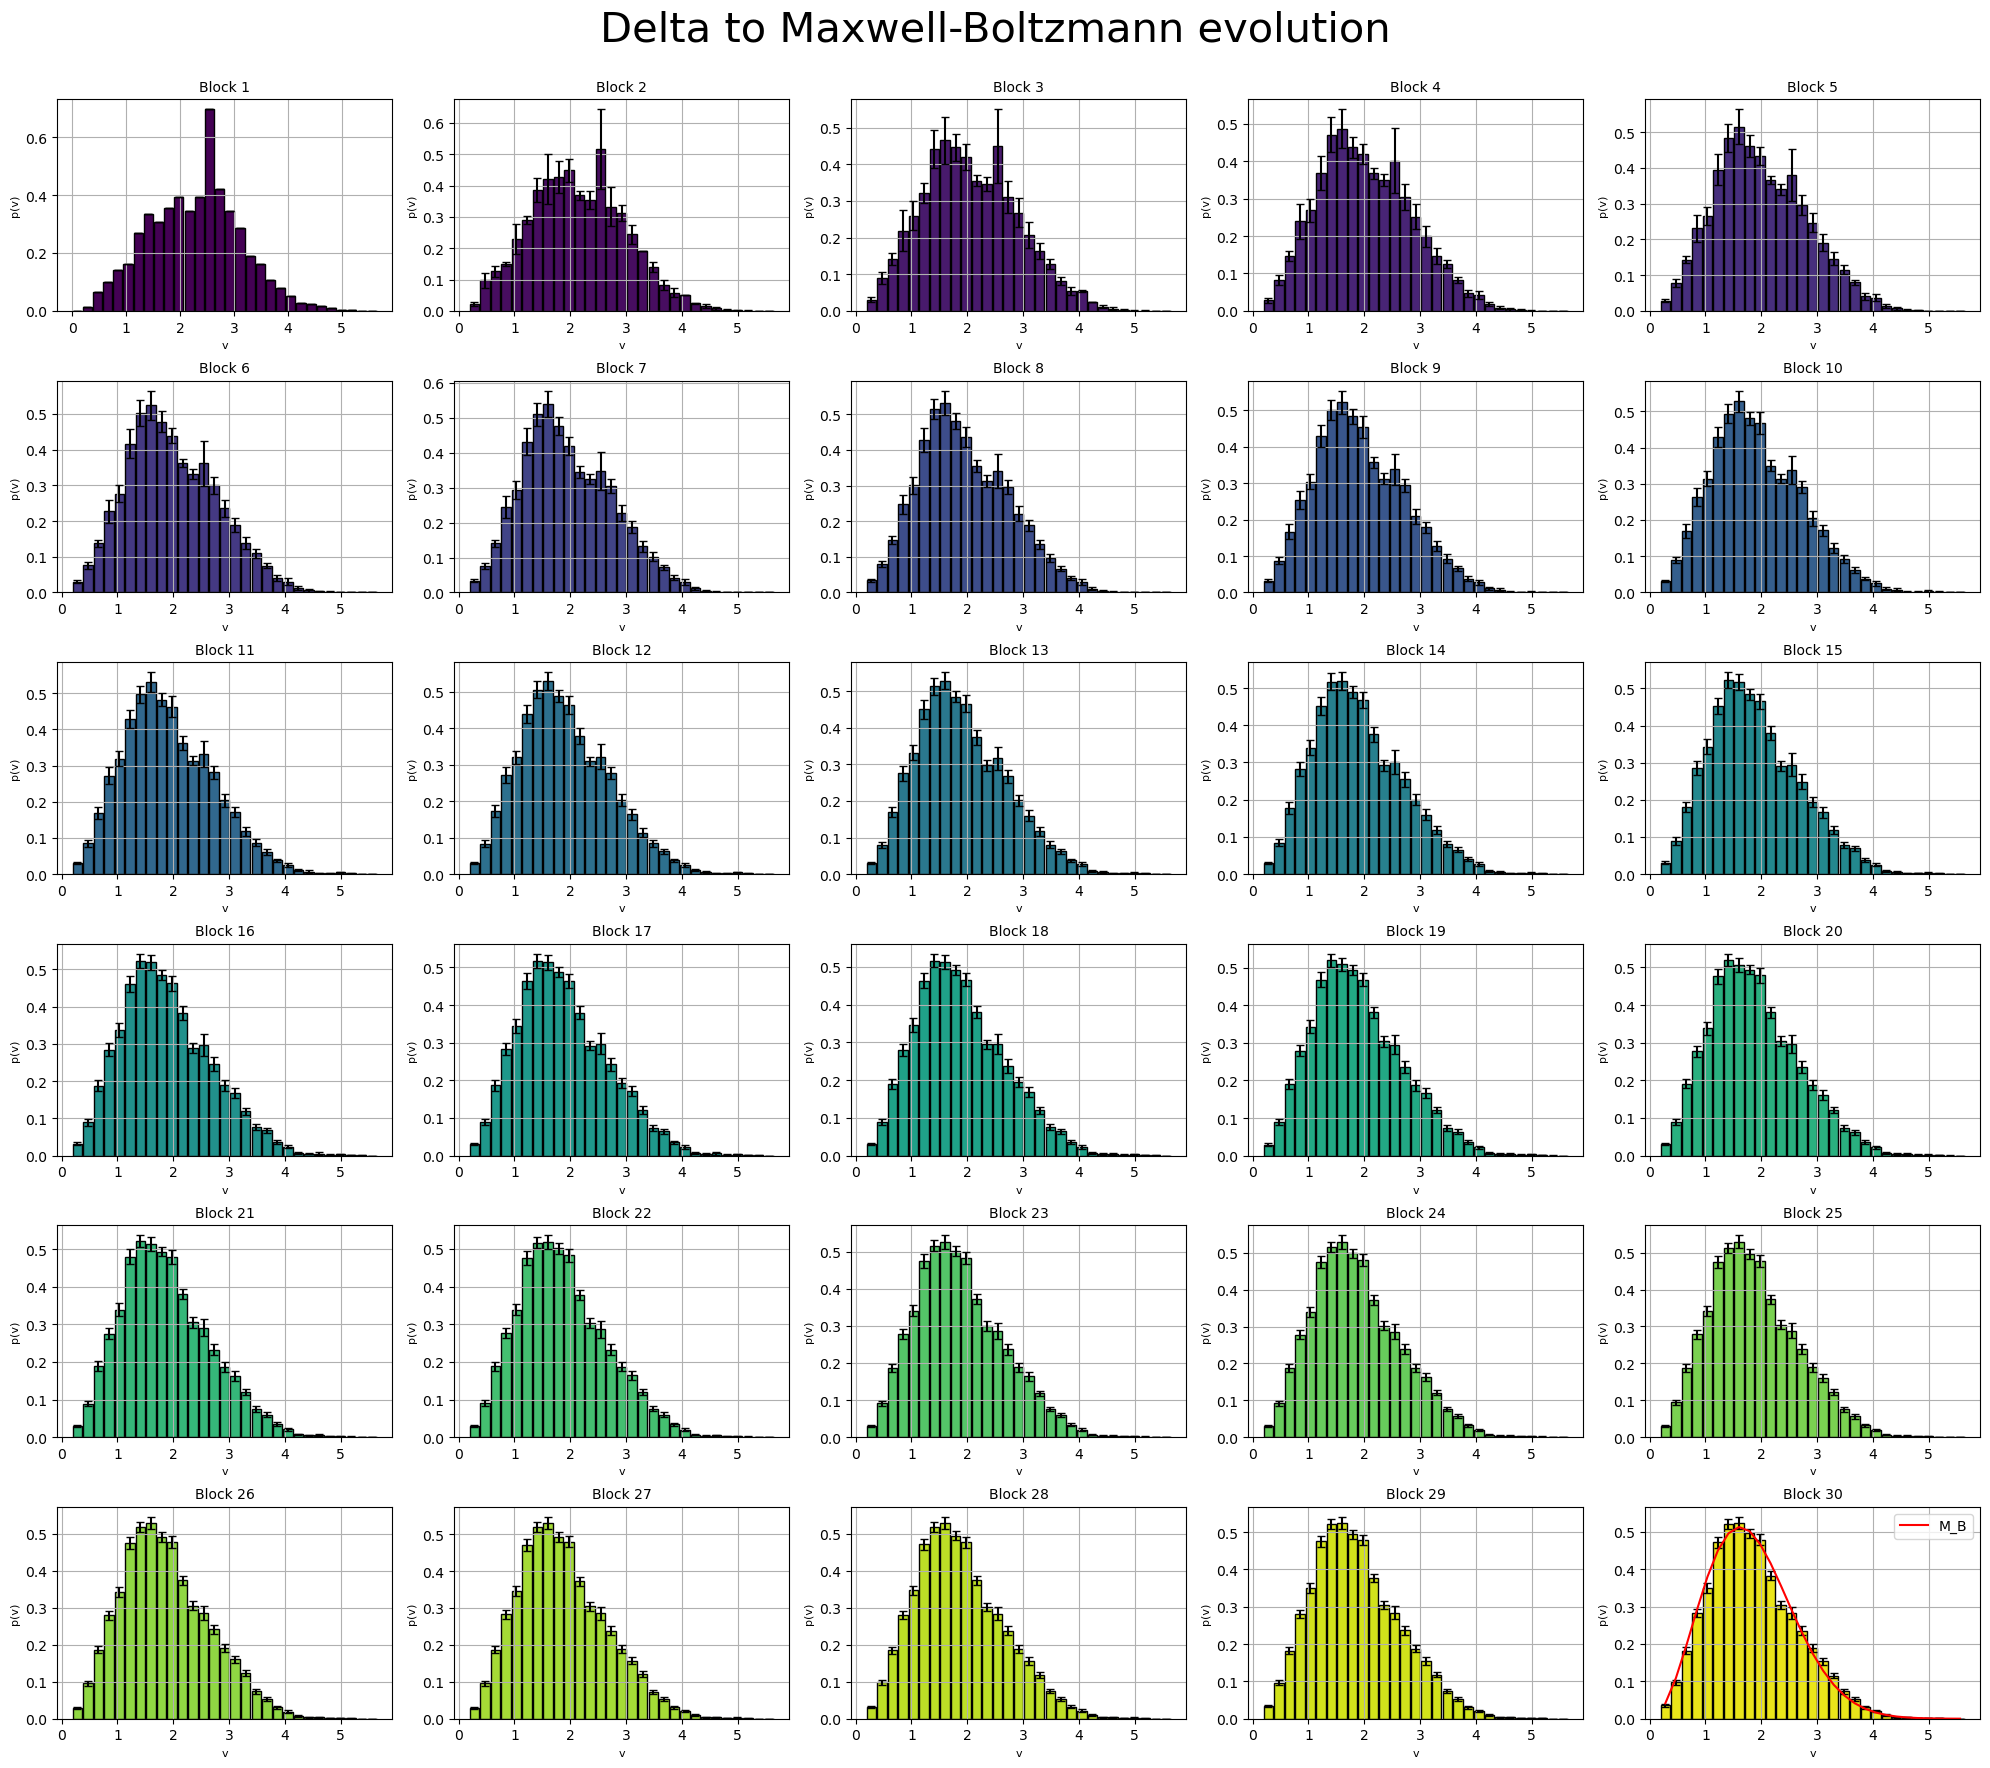

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def maxwell_boltzmann(x):
    return 1/(2*np.pi*1.31)**(3.0/2.0) * 4 * np.pi * x**2 * np.exp(-x**2 / (2 * 1.31))

with open("04.2/NSL_SIMULATOR/OUTPUT/pofv.dat") as f:
    content = f.read()

blocks = content.strip().split('\n\n')
n_blocks = len(blocks)

ncols = 5
nrows = (n_blocks + ncols - 1) // ncols

fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharex=False, sharey=False)
axs = axs.flatten()

cmap = plt.cm.viridis  
colors = [cmap(i / n_blocks) for i in range(n_blocks)]

for idx, block in enumerate(blocks):
    lines = block.strip().split('\n')[1:]
    x, y, yerr = [], [], []
    for line in lines:
        parts = line.split()
        if len(parts) >= 4:
            x.append(float(parts[0]))
            y.append(float(parts[2]))
            yerr.append(float(parts[3]))
    x = np.array(x)
    y = np.array(y)
    yerr = np.array(yerr)
    width = np.min(np.diff(x)) if len(x) > 1 else 1.0

    ax = axs[idx]
    ax.bar(x, y, width=width * 0.9, yerr=yerr, capsize=3, color=colors[idx], edgecolor='black')

    if idx == 29:
        ax.plot(x, maxwell_boltzmann(x), color='red', label='M_B')
        ax.legend()

    ax.set_title(f'Block {idx + 1}', fontsize=10)
    ax.set_xlabel('v', fontsize=8) 
    ax.set_ylabel('p(v)', fontsize=8)  
    ax.grid(True)

plt.tight_layout()
fig.suptitle('Delta to Maxwell-Boltzmann evolution', fontsize=30)
fig.subplots_adjust(top=0.93)
plt.show()



As expected the distribution gradually shifts away from the Dirac's delta (not well defined in block $1$ because the system quickly get rid of that configuration) to a well defined Maxwell-Boltzmann. In the last block histogram i performed a fit with the exact distribution to show the compatibility.

## Esercizio 04.3 ##
The scope of this final exercise is to see what happens when i change the direction of time in the simulation. I performed this task starting with the system equilibration, using the same conditions as the previous simulation i started at $T=2$ and initiated a $30$ blocks and $10^3$ step process. 

Now to perform the time inversion i have to correct some things:
1. adjust the starting temperature to match the last recorded from the clockwise simulation so that the system doesn't start in a far from equilibrium condition
2. swap, simply by changing the names, the files containing respectively the final and last to final step configurations, this will cause the system to naturally evolve anticlockwise without need of any change
3. adjust the initial configuration so that the particles are not confined in the half simulation box used at the start

With these conditions i started the anticlockwise simulation with exactly the same number of blocks and steps. 
Below are on the left the equilibration plots and on the right the time inverse simulation, all with errors calculated via the data blocking technique.

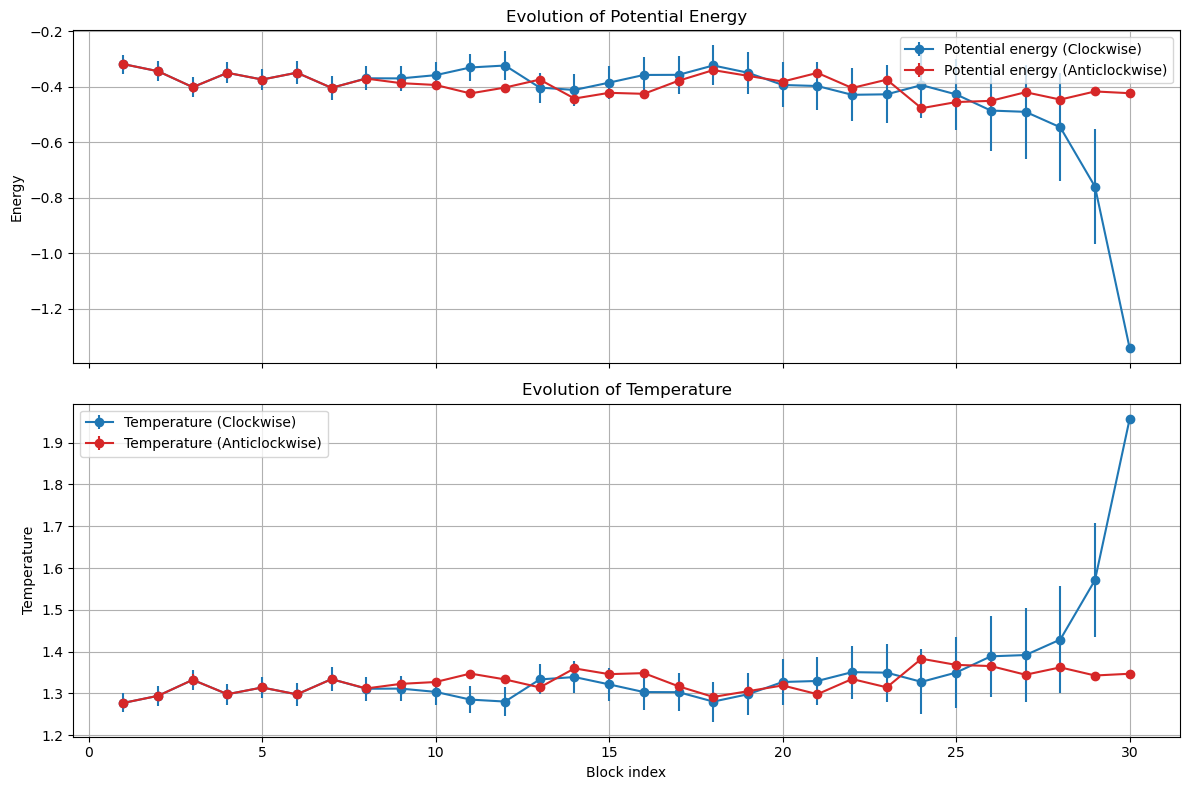

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def read_data(filename):
    with open(filename) as f:
        lines = f.read().strip().split('\n')[1:]  # Skip header
    x, y, yerr = [], [], []
    for line in lines:
        parts = line.split()
        if len(parts) >= 4:
            x.append(float(parts[0]))
            y.append(float(parts[1]))
            yerr.append(float(parts[3]))
    return np.array(x), np.array(y), np.array(yerr)

# Input files: [E_clockwise, E_anticlockwise, T_clockwise, T_anticlockwise]
files = [
    "04.2/NSL_SIMULATOR/OUTPUT/potential_energy.dat",
    "04.3/NSL_SIMULATOR/OUTPUT/potential_energy.dat",
    "04.2/NSL_SIMULATOR/OUTPUT/temperature.dat",
    "04.3/NSL_SIMULATOR/OUTPUT/temperature.dat"
]

labels = [
    "Potential energy (Clockwise)",
    "Potential energy (Anticlockwise)",
    "Temperature (Clockwise)",
    "Temperature (Anticlockwise)"
]

colors = ['tab:blue', 'tab:red', 'tab:blue', 'tab:red']

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot potential energy
for i in range(2):
    x, y, yerr = read_data(files[i])
    
    # Invert time for Clockwise data (i == 0)
    if i == 0:
        x = x[::-1]
    
    axs[0].errorbar(x, y, yerr=yerr, label=labels[i], fmt='-o', color=colors[i])

axs[0].set_title("Evolution of Potential Energy")
axs[0].set_ylabel("Energy")
axs[0].legend()
axs[0].grid(True)

# Plot temperature
for i in range(2, 4):
    x, y, yerr = read_data(files[i])
    
    # Invert time for Clockwise data (i == 2)
    if i == 2:
        x = x[::-1]

    axs[1].errorbar(x, y, yerr=yerr, label=labels[i], fmt='-o', color=colors[i])

axs[1].set_title("Evolution of Temperature")
axs[1].set_xlabel("Block index")
axs[1].set_ylabel("Temperature")
axs[1].legend()
axs[1].grid(True)

fig.tight_layout()
plt.show()



Here are shown istanteneous values, as expected the system evolving backwards (red plots) does not reverse to the initial temperature and energy conditions but maintains a stable behavior, if it were to return to the initial conditions it meant a violation of the second principle of thermodynamics stating that a closed system cannot evolve from a high entropic to a lower entropic configuration, this is the physical explanation but code wise is likely not what is exactly happening.

As can be seen, as the verlet algorithm is perfectly time simmetric, it tries to reproduce the exact path of the clockwise configuration but, at some point, it encounters rounding differences that makes it deviate and never return to the initial perfect configuration.

This is exactly a demostration, the initial configuration is very low entropic and by evolving the system set itself in a higher entropic one, so at the end the anticlockwise evolution leads to a new, different, equilibrium configuration that remains similar to where the simulaton ended in the clockwise direction.